# XGBoost Lasso — v3

## What changed from v2
- All CV consolidated into **one 12-fold expanding-window loop** covering full year 2024
- Naive baseline (lag 24h) evaluated on **same windows** as model → fair MASE per fold
- All predictions clipped to ≥ 0
- Per-month visualization: best + worst week side by side
- Final model trained on 80% for feature importance and seasonal plots

## Structure
| Section | Description |
|---|---|
| Preprocessing | Load, clean, engineer features (identical to v2) |
| 12-fold CV | Train, predict, evaluate model + naive per month |
| Summary table | MAE / RMSE / MASE per fold + averages |
| Monthly plots | Best + worst week per fold (12 figures) |
| Final model | Train on 80% train set |
| Feature importance | Rank + plot |
| Seasonal forecasts | 14-day plots per season |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [3]:
df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print("Shape:", df.shape)

Shape: (52585, 81)


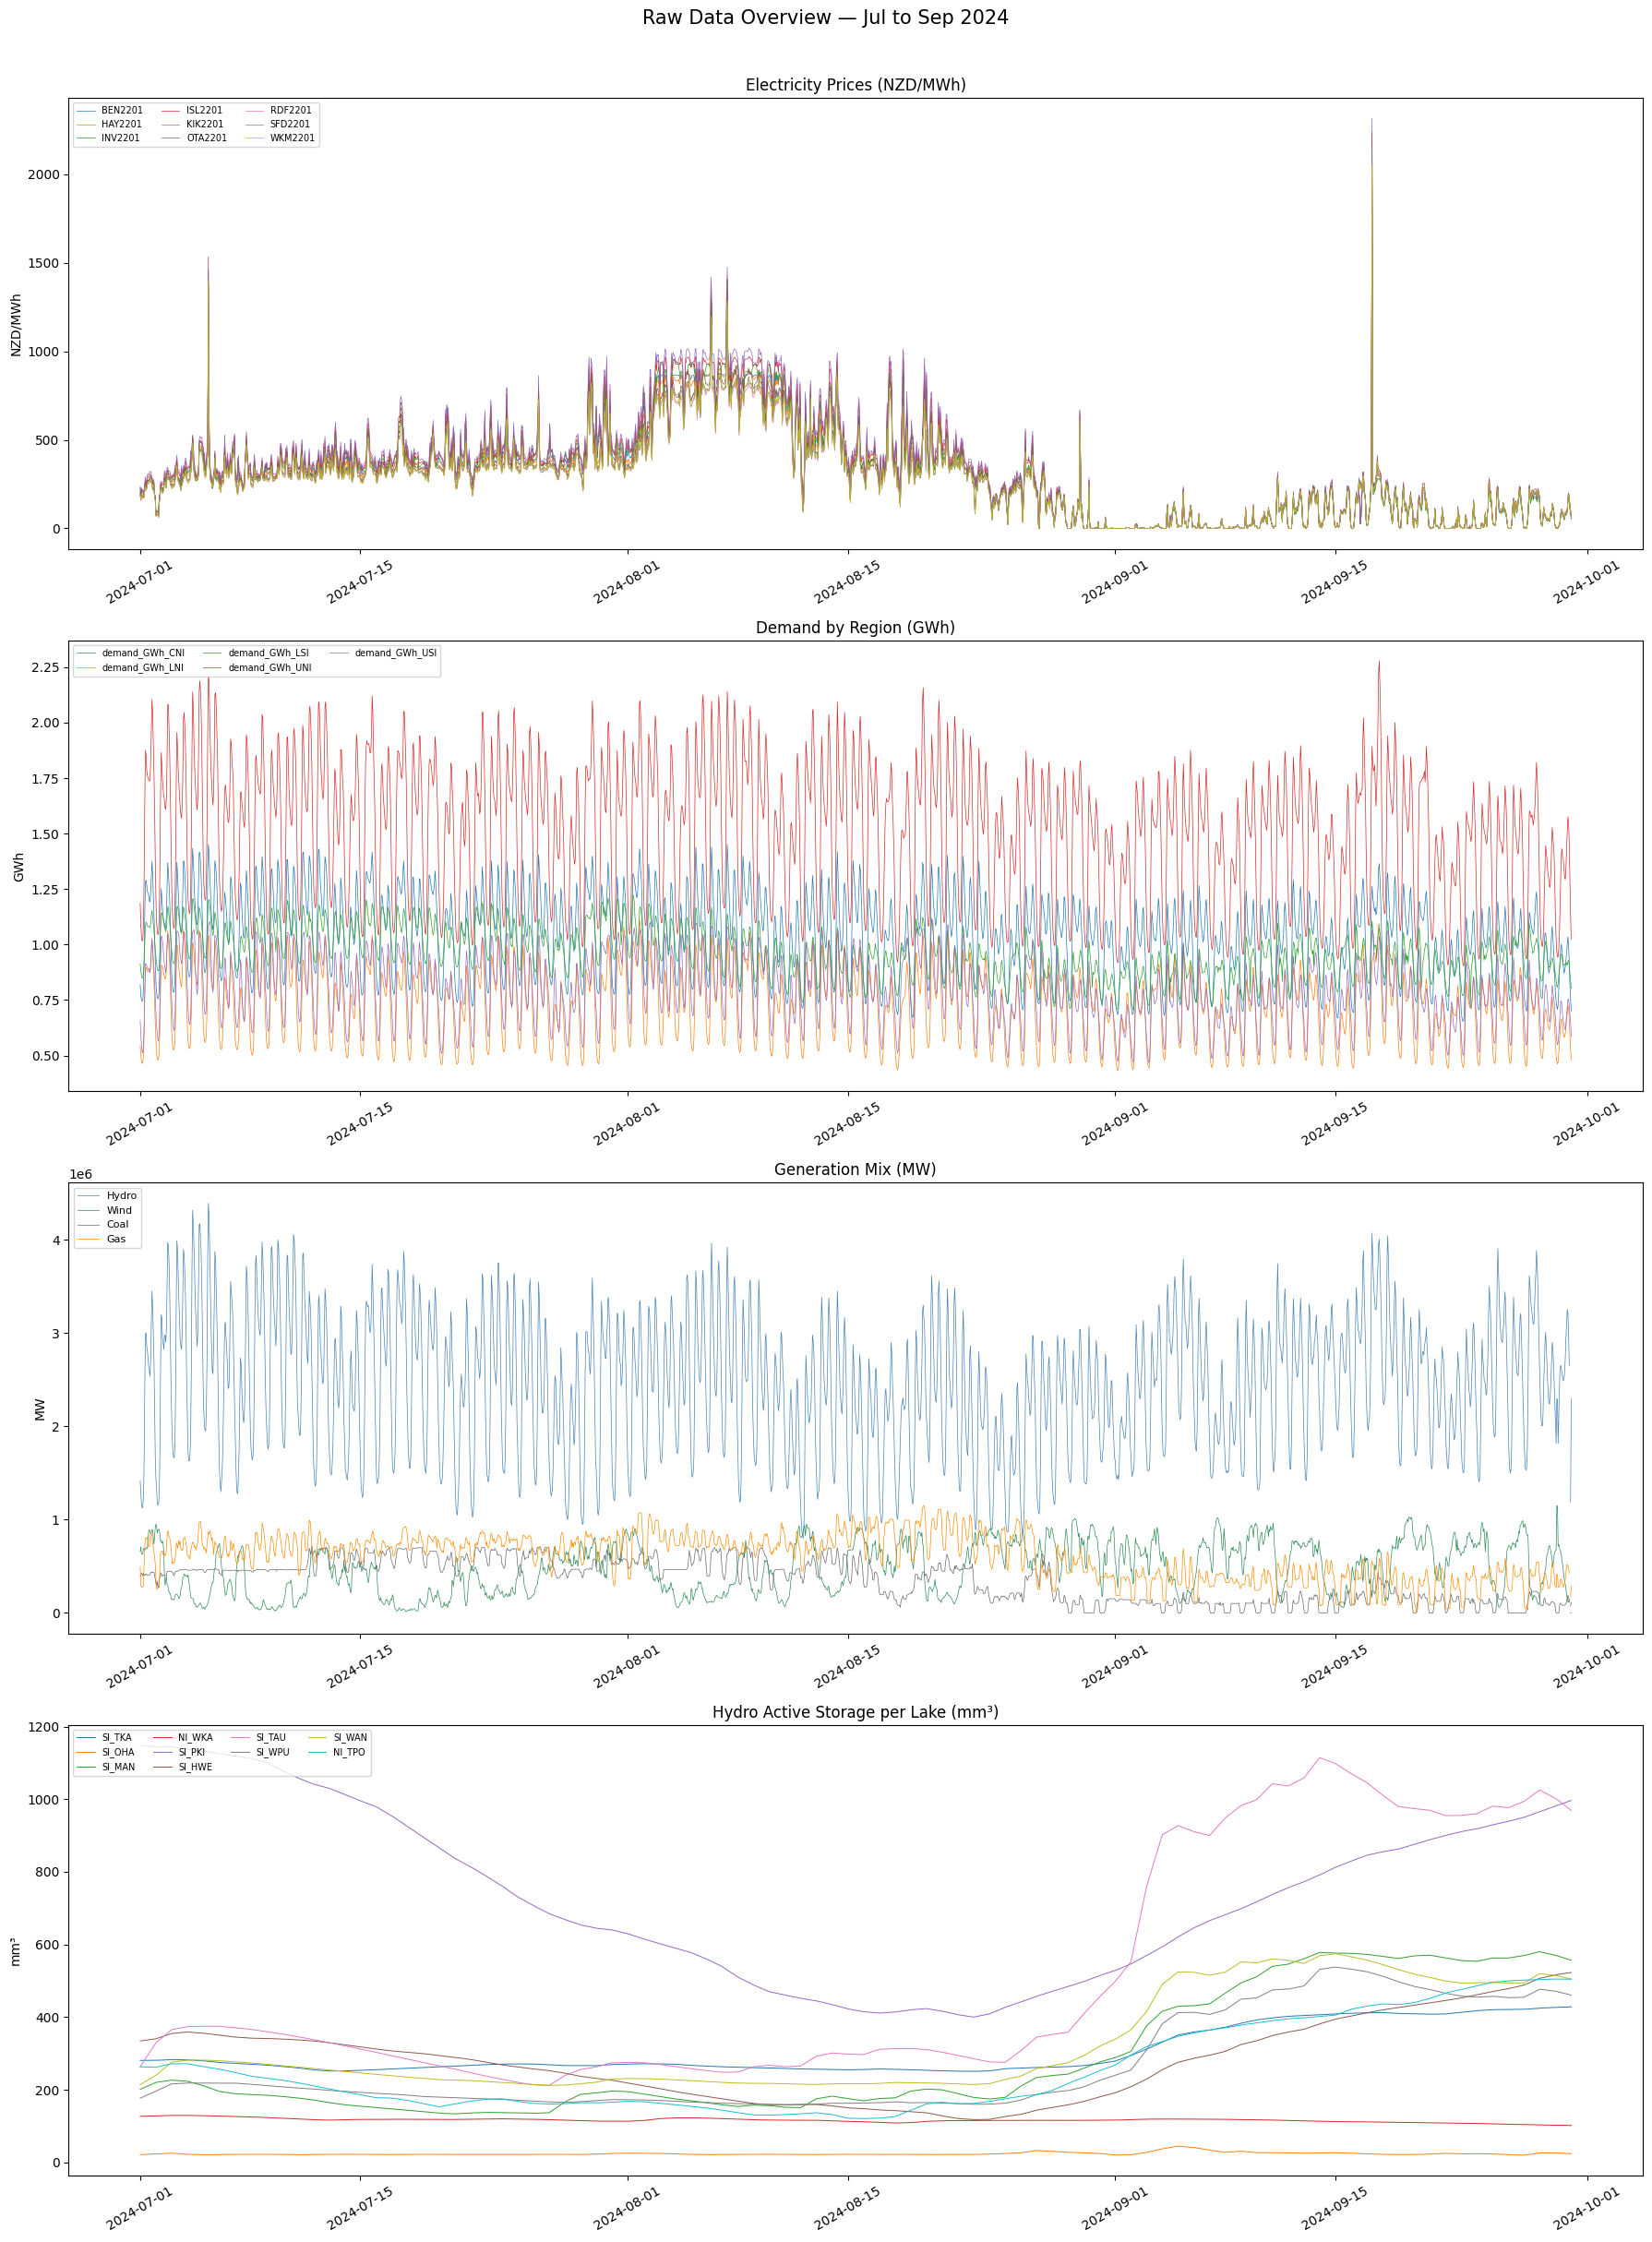

In [4]:
# EDA — Raw data overview Jul–Sep 2024

mask = (df["datetime_utc12"] >= "2024-07-01") & (df["datetime_utc12"] <= "2024-09-30")
df_plot = df[mask]

fig, axes = plt.subplots(4, 1, figsize=(18, 24))
fig.suptitle("Raw Data Overview — Jul to Sep 2024", fontsize=15, y=1.01)

price_cols = [c for c in df.columns if "el_price" in c]
for col in price_cols:
    axes[0].plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col.split("_")[-1])
axes[0].set_title("Electricity Prices (NZD/MWh)"); axes[0].set_ylabel("NZD/MWh")
axes[0].legend(fontsize=7, ncol=3, loc="upper left")

demand_cols = [c for c in df.columns if "demand_GWh" in c]
for col in demand_cols:
    axes[1].plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col)
axes[1].set_title("Demand by Region (GWh)"); axes[1].set_ylabel("GWh")
axes[1].legend(fontsize=7, ncol=3, loc="upper left")

for col, color in zip(["Hydro","Wind","Coal","Gas"], ["steelblue","seagreen","dimgray","darkorange"]):
    axes[2].plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col, color=color)
axes[2].set_title("Generation Mix (MW)"); axes[2].set_ylabel("MW")
axes[2].legend(fontsize=8, loc="upper left")

storage_cols = [c for c in df.columns if "active_storage" in c]
for col in storage_cols:
    axes[3].plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.7, label=col.split("__")[0])
axes[3].set_title("Hydro Active Storage per Lake (mm³)"); axes[3].set_ylabel("mm³")
axes[3].legend(fontsize=7, ncol=4, loc="upper left")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

In [5]:
# ── Preprocessing ────────────────────────────────────────────────────────────

df = df.ffill()

# 24h lag on leakage-prone columns
cols_to_shift_24h = [
    c for c in df.columns if "el_price" in c and c != target_col
] + [
    "Coal","Diesel","Ele","Gas","Geo","Hydro","Solar","Wind","Wood",
    "demand_GWh_CNI","demand_GWh_LNI","demand_GWh_LSI","demand_GWh_UNI","demand_GWh_USI",
    "avg_flow_MW","peak_flow_MW","Direction"
]
for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

# Cyclical time features
df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]    = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]    = np.cos(2*np.pi*df["dayofweek"]/7)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

# Target lag features (input features, leakage-safe)
df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

# Rolling features
for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window).std()

# Drop warmup NaNs
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows after cleanup: {len(df)}  (removed {rows_before - len(df)})")

Rows after cleanup: 43825  (removed 8760)


In [6]:
# Define X and y

exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (43825, 99)


In [7]:
# ── 12-Fold Expanding-Window CV ───────────────────────────────────────────────
#
# test_size=720 ≈ 1 month (30 days × 24h)
# 12 folds × 720h = 8640h ≈ 12 months → covers full 2024
#
# Each fold:
#   - Trains XGBoost on all data before the test window (expanding)
#   - Predicts the test window, clips to ≥ 0
#   - Naive baseline = target_lag_24h (yesterday same hour, no training needed)
#   - Computes MAE, RMSE, MASE on the same window → fair comparison

MODEL_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=12, test_size=720)

fold_results = []   # store everything for later visualisation

print(f"{'Fold':>4}  {'Month':>10}  {'MAE model':>10}  {'MAE naive':>10}  {'RMSE model':>11}  {'RMSE naive':>11}  {'MASE':>6}")
print("-" * 72)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # --- XGBoost ---
    m = XGBRegressor(**MODEL_PARAMS)
    m.fit(X_tr, y_tr)
    y_model = np.clip(m.predict(X_te), 0, None)

    # --- Naive baseline ---
    y_naive = X_te["target_lag_24h"].values

    # --- Metrics ---
    mae_m  = mean_absolute_error(y_te, y_model)
    mae_n  = mean_absolute_error(y_te, y_naive)
    rmse_m = np.sqrt(mean_squared_error(y_te, y_model))
    rmse_n = np.sqrt(mean_squared_error(y_te, y_naive))
    mase   = mae_m / mae_n

    timestamps = df["datetime_utc12"].iloc[test_idx].values
    month_label = pd.Timestamp(timestamps[0]).strftime("%b %Y")

    fold_results.append({
        "fold":        fold,
        "month":       month_label,
        "timestamps":  timestamps,
        "y_actual":    y_te.values,
        "y_model":     y_model,
        "y_naive":     y_naive,
        "mae_model":   mae_m,
        "mae_naive":   mae_n,
        "rmse_model":  rmse_m,
        "rmse_naive":  rmse_n,
        "mase":        mase,
    })

    print(f"{fold:>4}  {month_label:>10}  {mae_m:>10.2f}  {mae_n:>10.2f}  "
          f"{rmse_m:>11.2f}  {rmse_n:>11.2f}  {mase:>6.3f}")

Fold       Month   MAE model   MAE naive   RMSE model   RMSE naive    MASE
------------------------------------------------------------------------
   1    Jan 2024       46.75       58.95        67.24        92.48   0.793
   2    Feb 2024       42.78       67.92        63.88       103.88   0.630
   3    Mar 2024       31.26       40.17        41.30        56.58   0.778
   4    Apr 2024       35.30       42.61        47.24        61.04   0.828
   5    May 2024       71.70       95.20       249.08       327.57   0.753
   6    Jun 2024       39.68       41.62        68.00        57.19   0.953
   7    Jul 2024       65.91       75.06       102.33       122.08   0.878
   8    Aug 2024      125.12      103.60       167.54       152.19   1.208
   9    Sep 2024       41.46       54.34        92.78       128.11   0.763
  10    Oct 2024       24.33       27.96        31.84        40.99   0.870
  11    Nov 2024       21.89       30.64        30.40        47.11   0.714
  12    Dec 2024       32.6

In [8]:
# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([{
    "Month":      r["month"],
    "MAE model":  r["mae_model"],
    "MAE naive":  r["mae_naive"],
    "RMSE model": r["rmse_model"],
    "RMSE naive": r["rmse_naive"],
    "MASE":       r["mase"],
    "Beats naive": "✓" if r["mase"] < 1 else "✗"
} for r in fold_results])

# Averages row
avg_row = pd.DataFrame([{
    "Month":      "AVERAGE",
    "MAE model":  summary["MAE model"].mean(),
    "MAE naive":  summary["MAE naive"].mean(),
    "RMSE model": summary["RMSE model"].mean(),
    "RMSE naive": summary["RMSE naive"].mean(),
    "MASE":       summary["MASE"].mean(),
    "Beats naive": f"{(summary['MASE'] < 1).sum()} / 12"
}])

summary_full = pd.concat([summary, avg_row], ignore_index=True)

pd.set_option("display.float_format", "{:.2f}".format)
print(summary_full.to_string(index=False))

   Month  MAE model  MAE naive  RMSE model  RMSE naive  MASE Beats naive
Jan 2024      46.75      58.95       67.24       92.48  0.79           ✓
Feb 2024      42.78      67.92       63.88      103.88  0.63           ✓
Mar 2024      31.26      40.17       41.30       56.58  0.78           ✓
Apr 2024      35.30      42.61       47.24       61.04  0.83           ✓
May 2024      71.70      95.20      249.08      327.57  0.75           ✓
Jun 2024      39.68      41.62       68.00       57.19  0.95           ✓
Jul 2024      65.91      75.06      102.33      122.08  0.88           ✓
Aug 2024     125.12     103.60      167.54      152.19  1.21           ✗
Sep 2024      41.46      54.34       92.78      128.11  0.76           ✓
Oct 2024      24.33      27.96       31.84       40.99  0.87           ✓
Nov 2024      21.89      30.64       30.40       47.11  0.71           ✓
Dec 2024      32.65      36.89      172.90      230.59  0.89           ✓
 AVERAGE      48.23      56.25       94.54      118

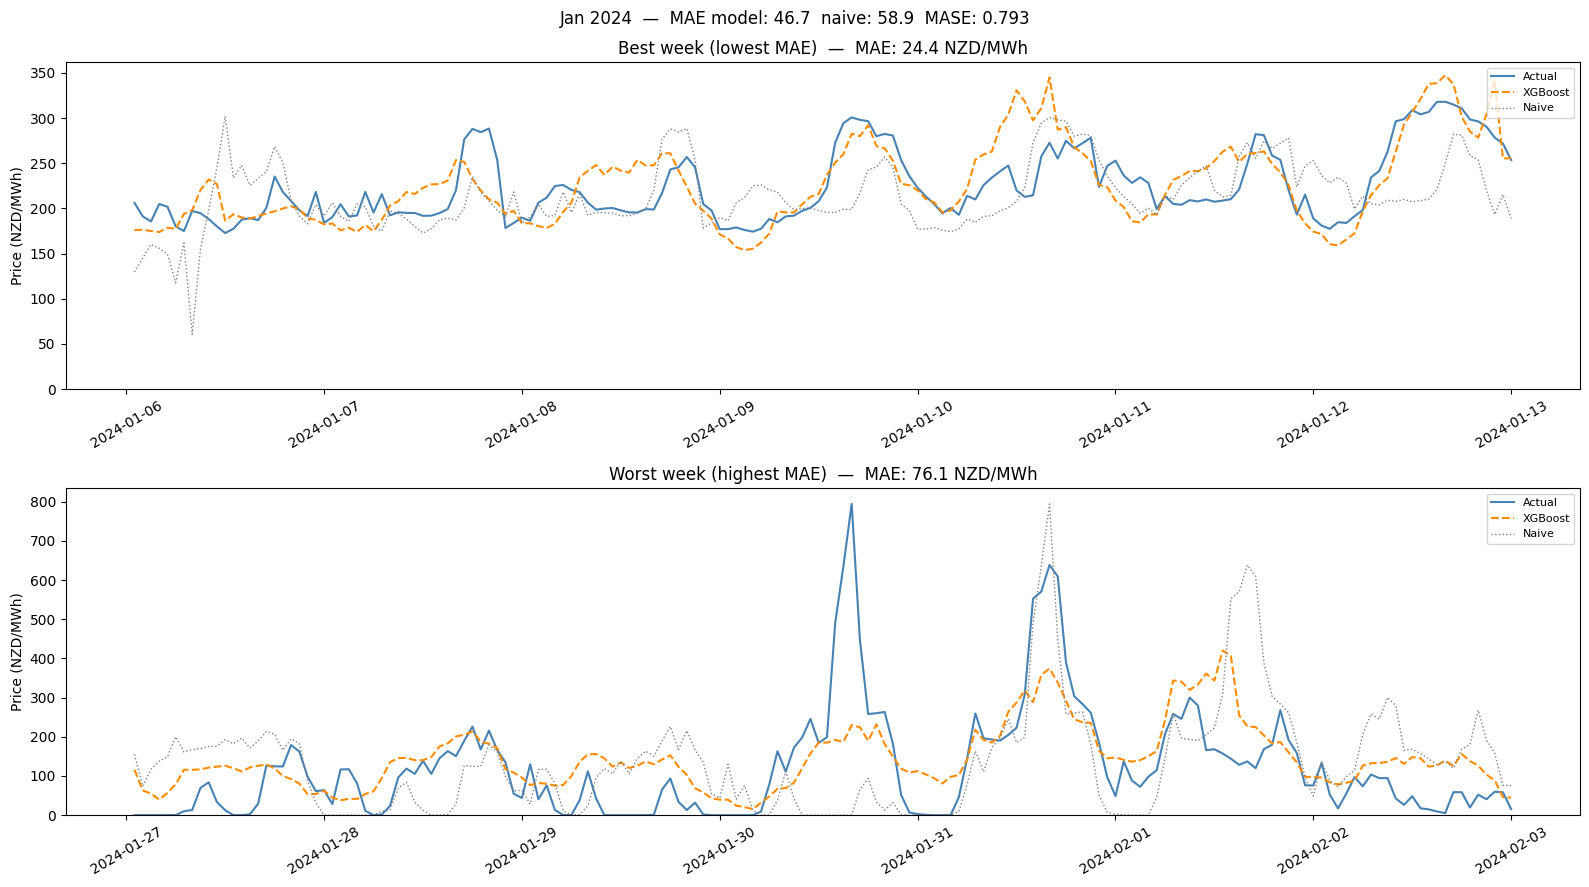

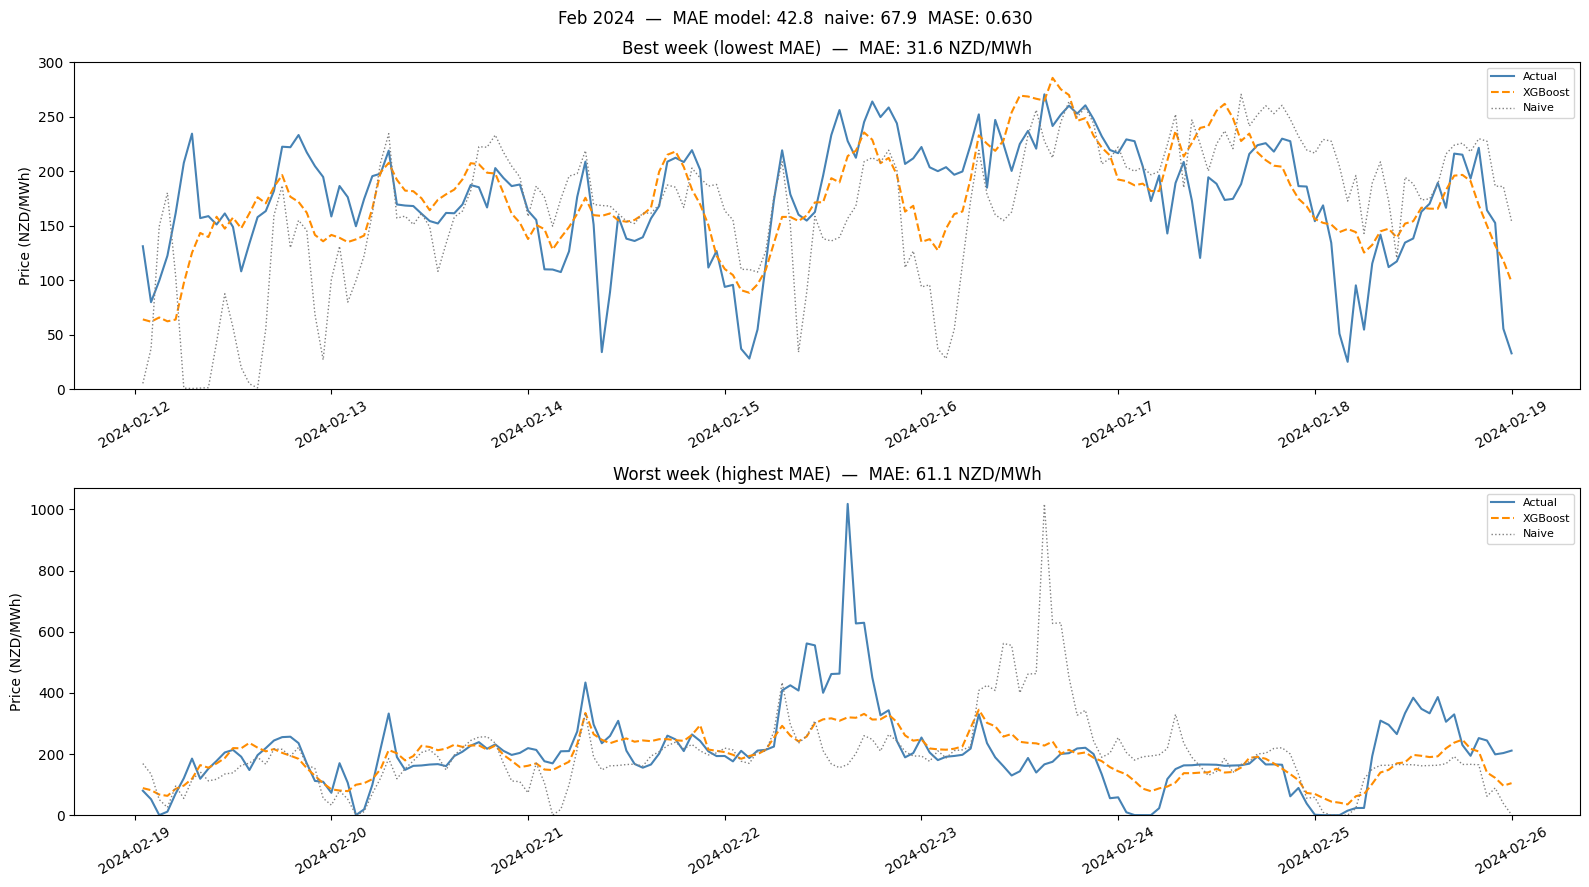

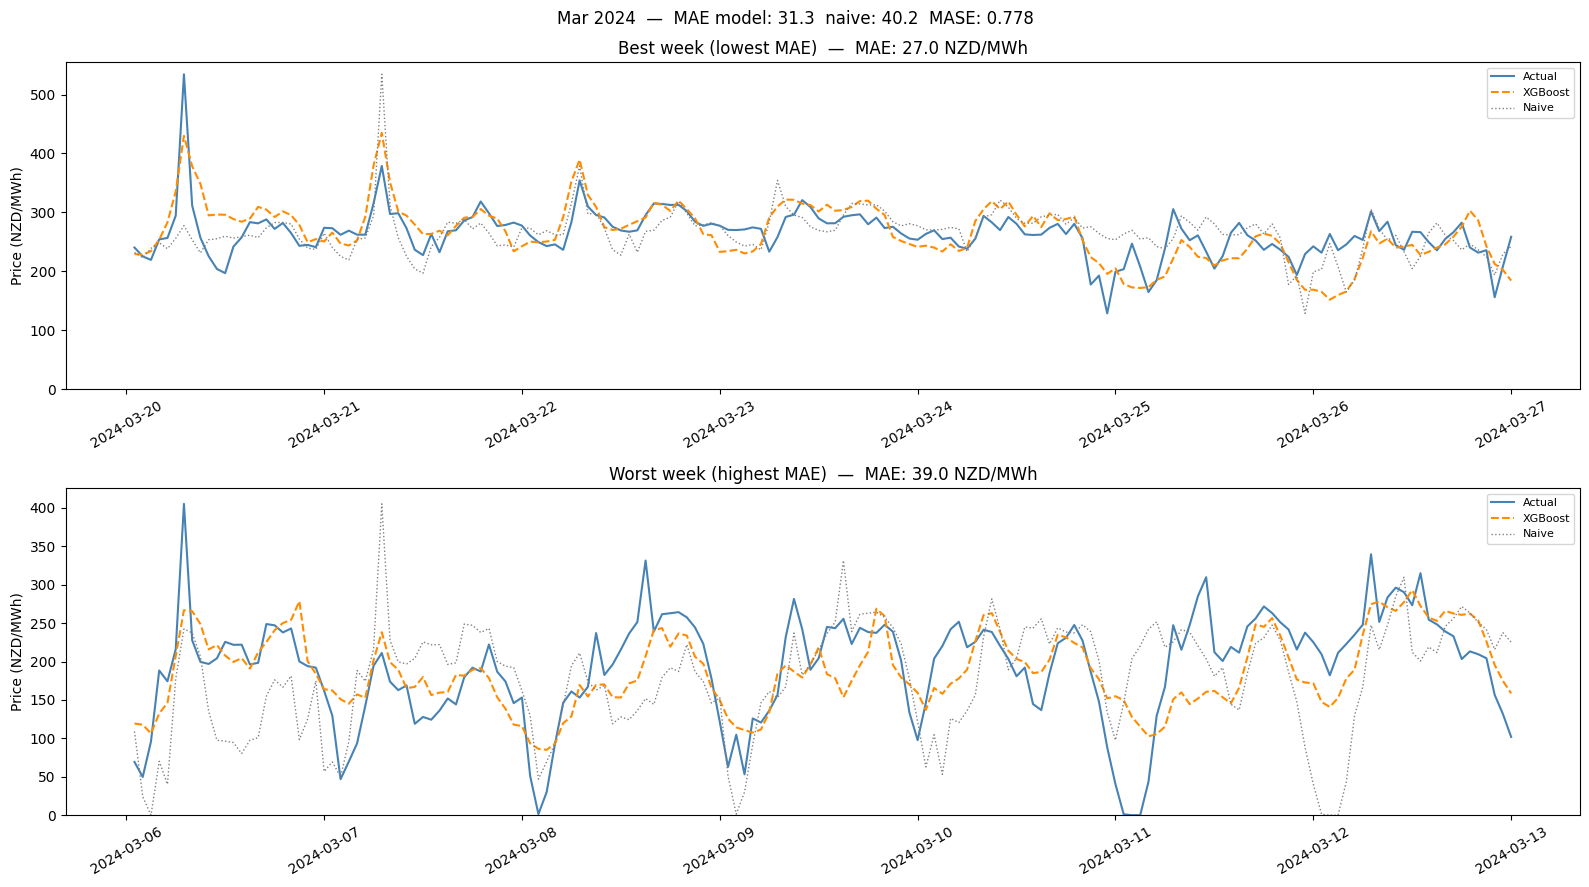

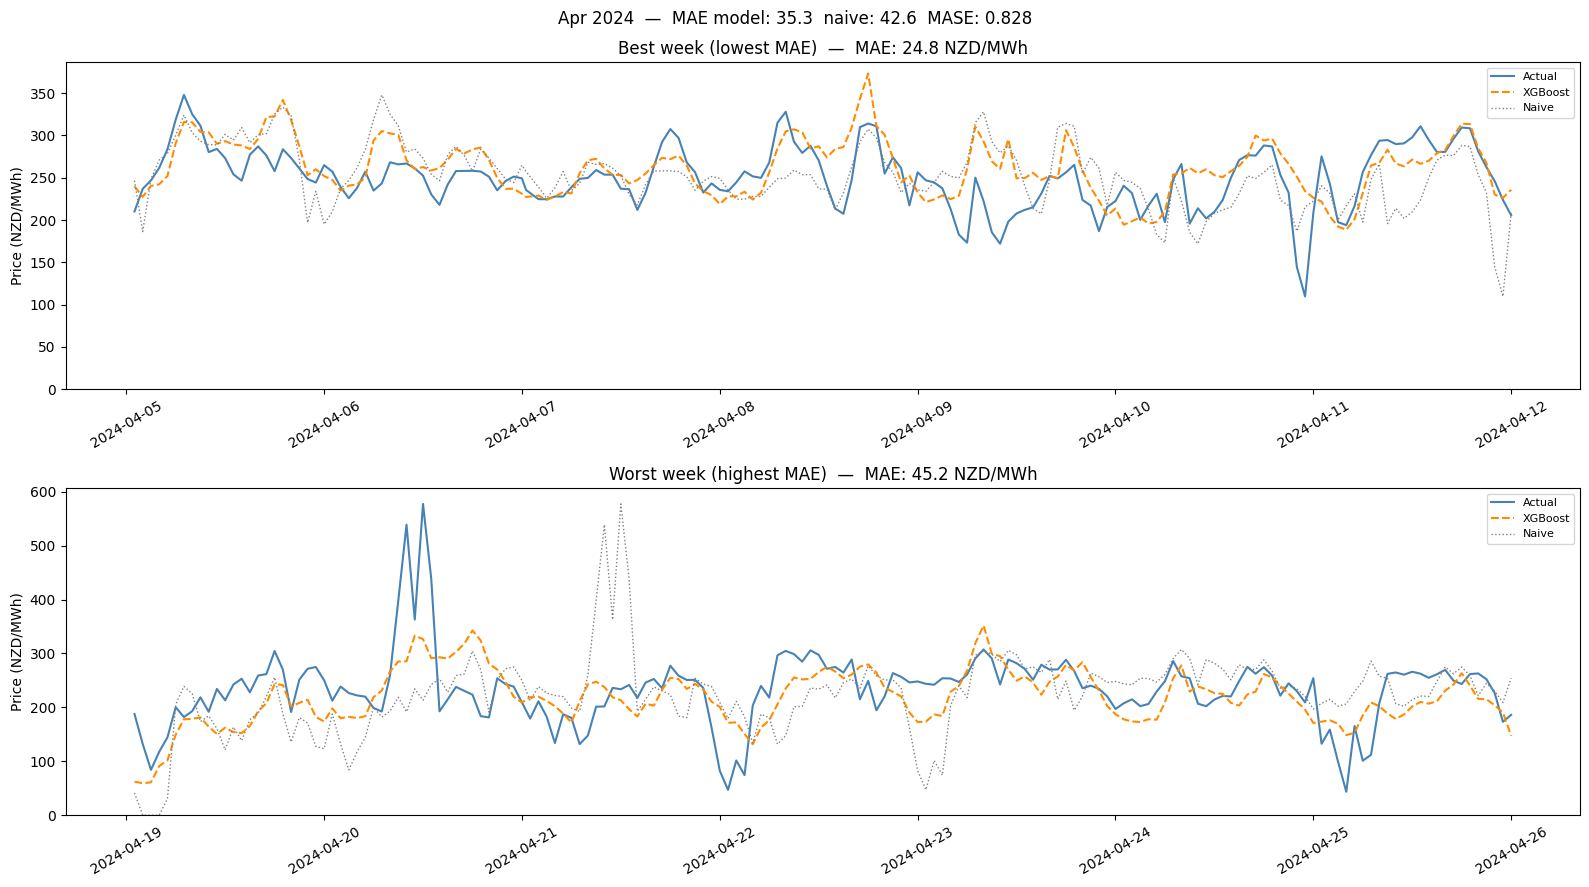

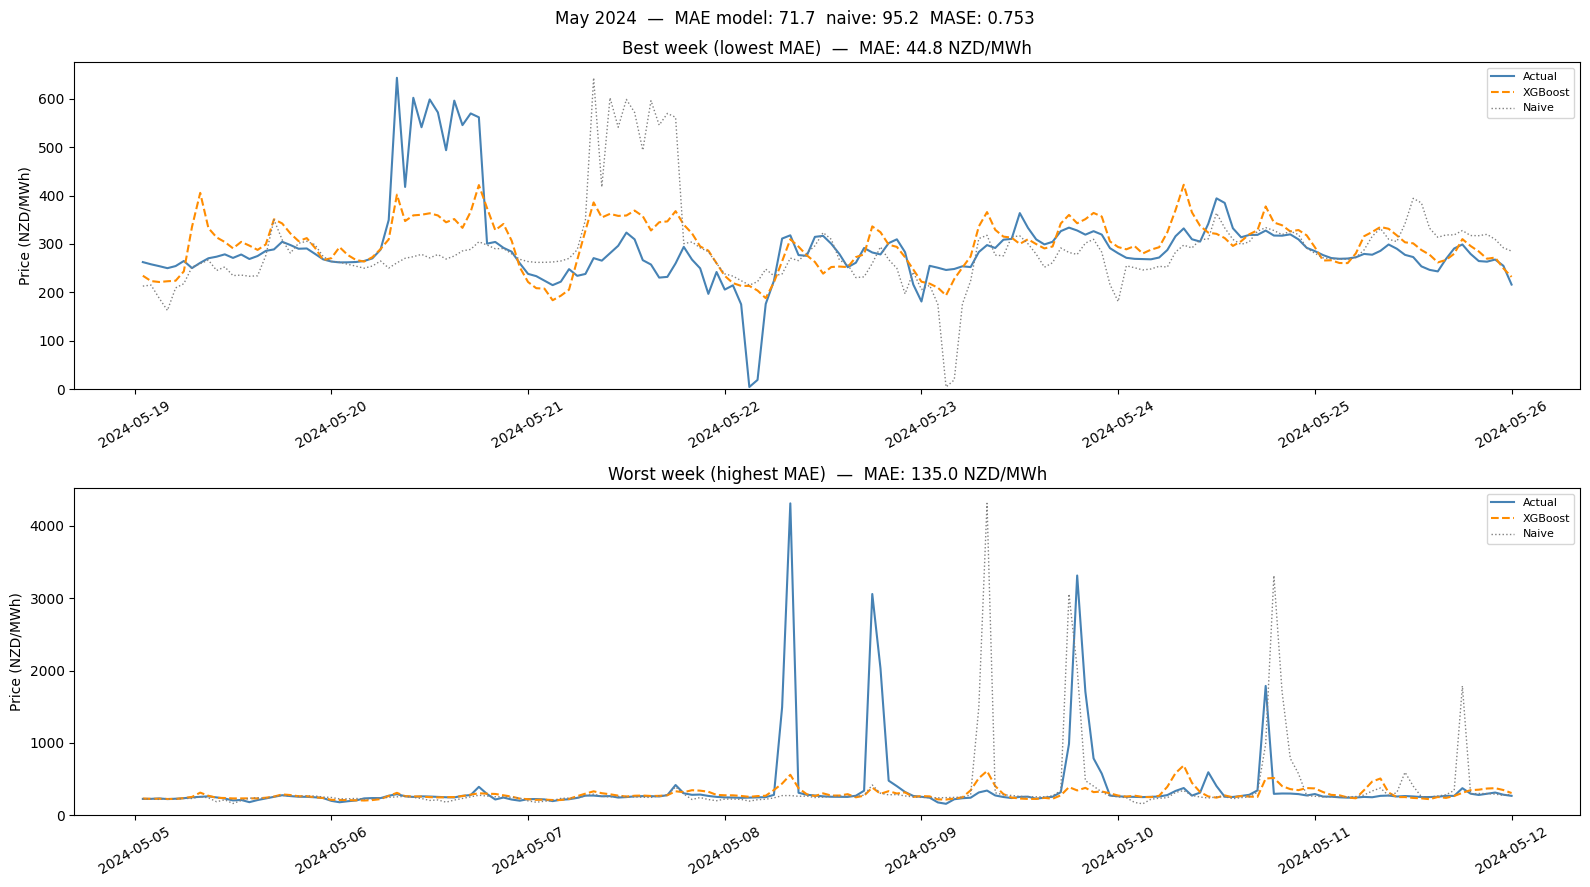

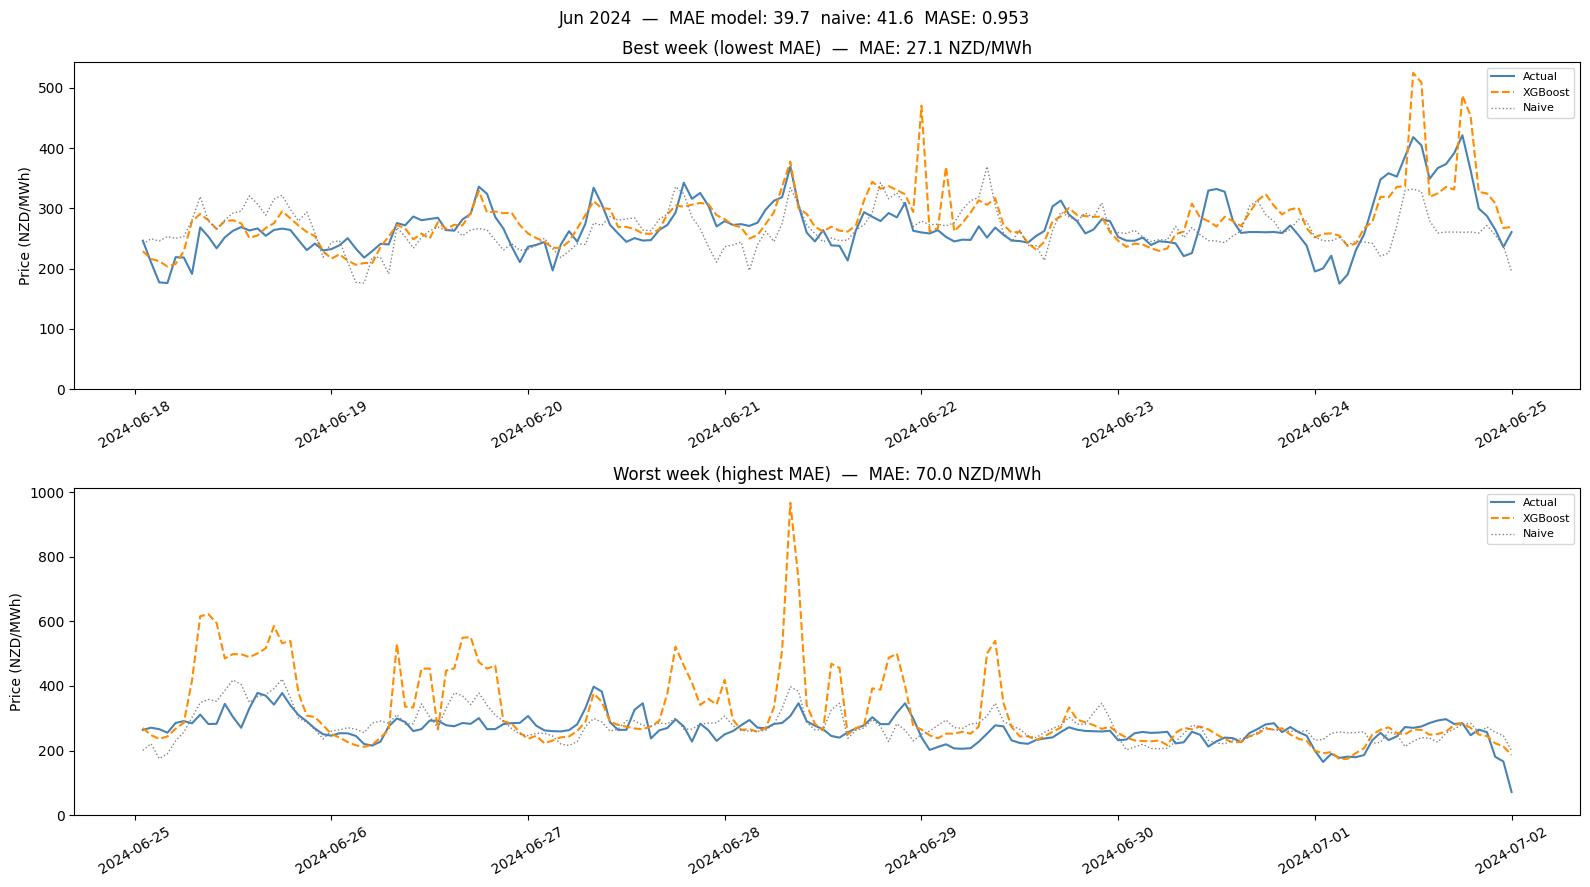

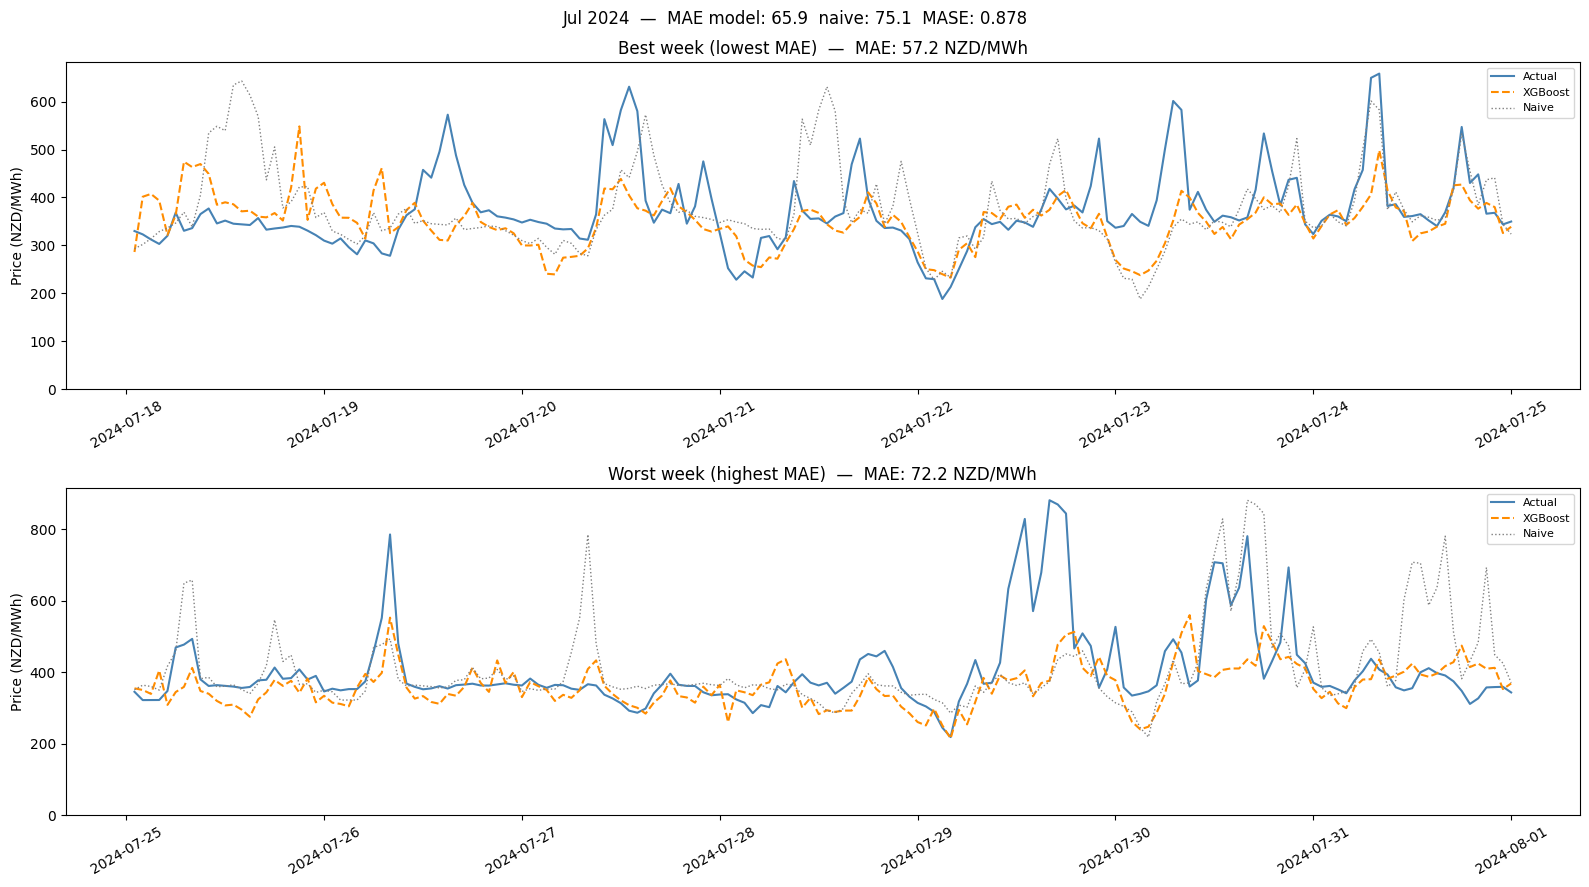

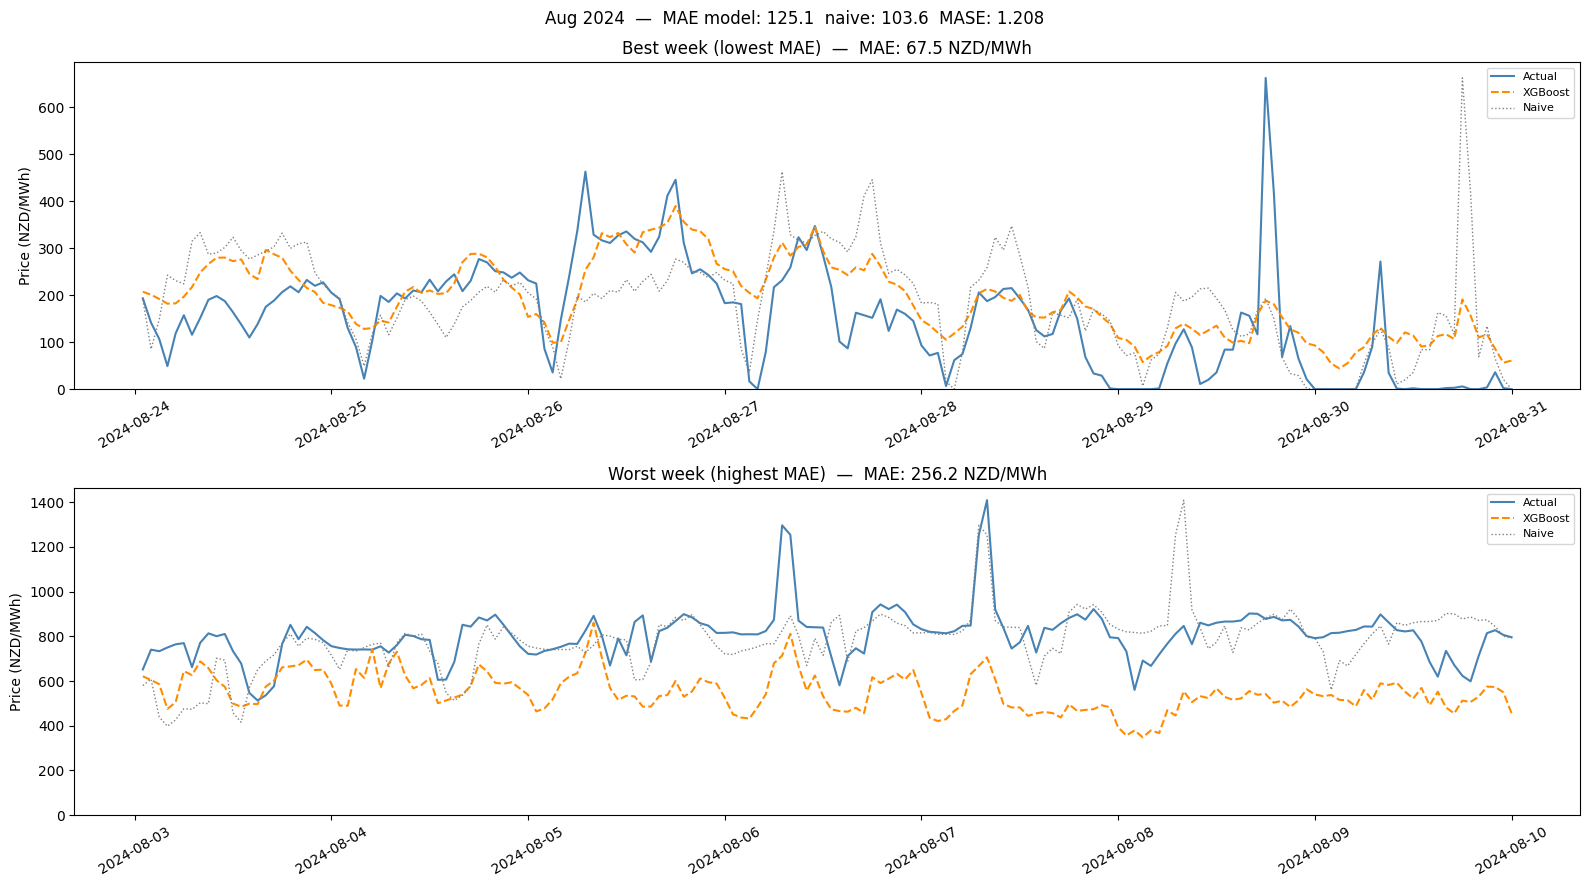

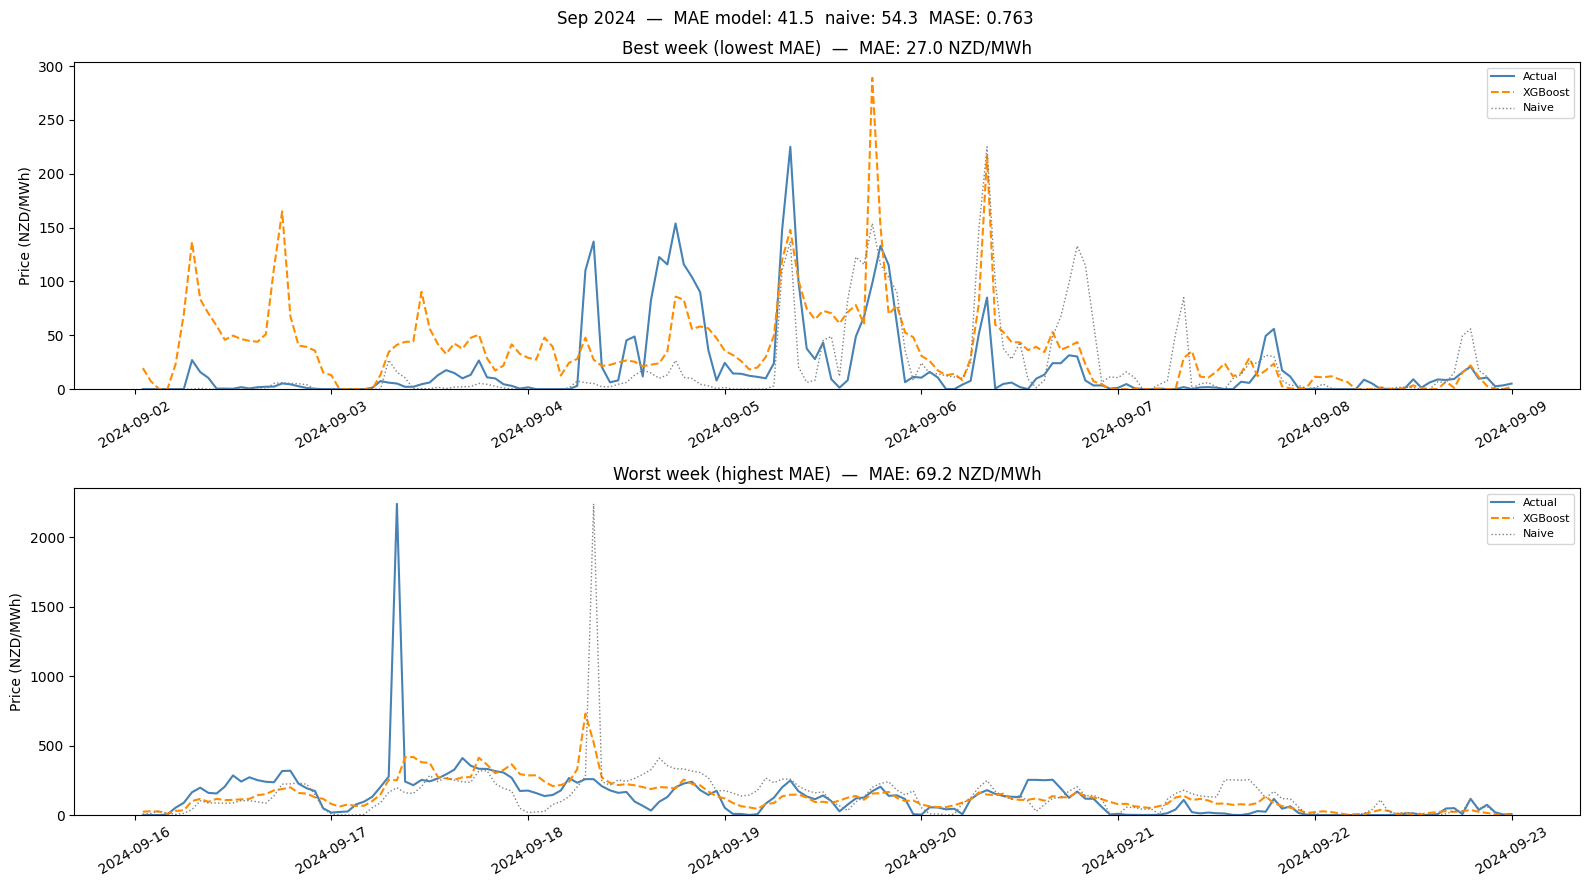

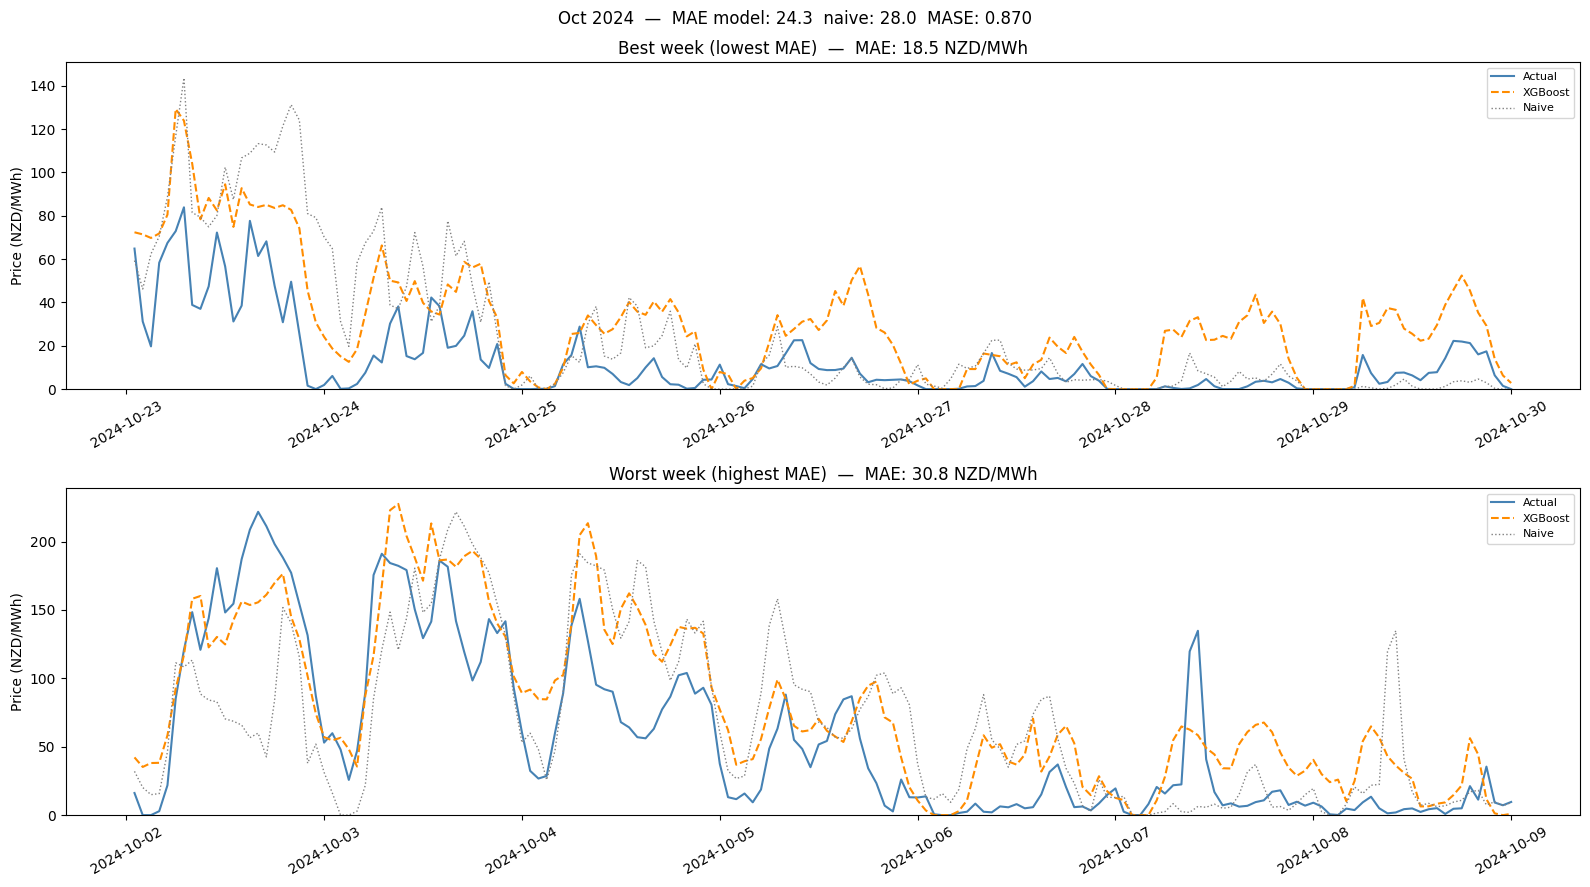

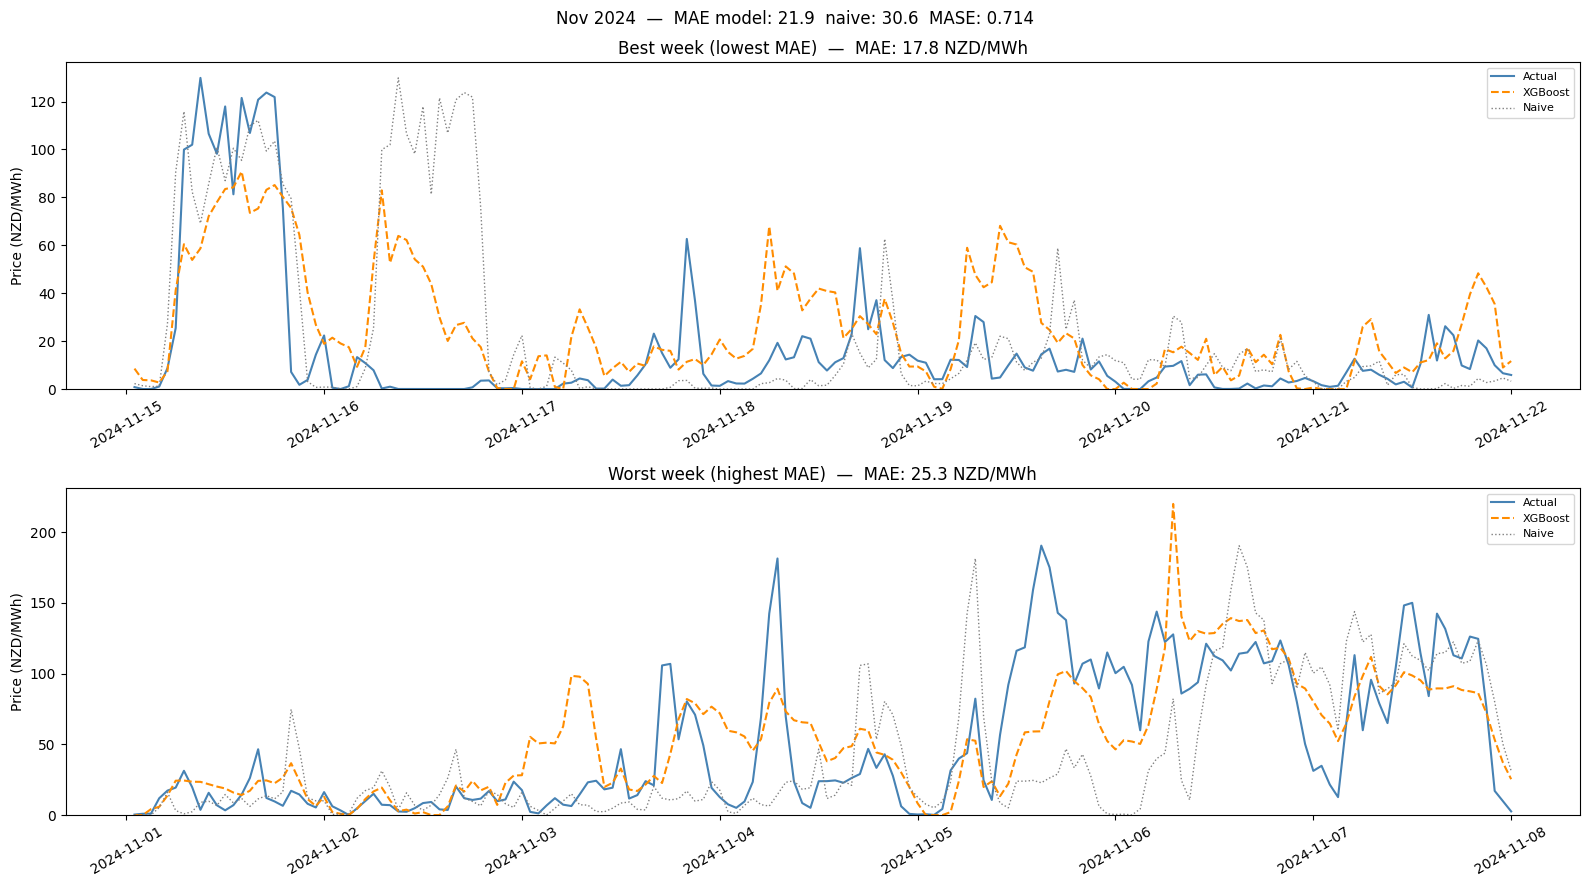

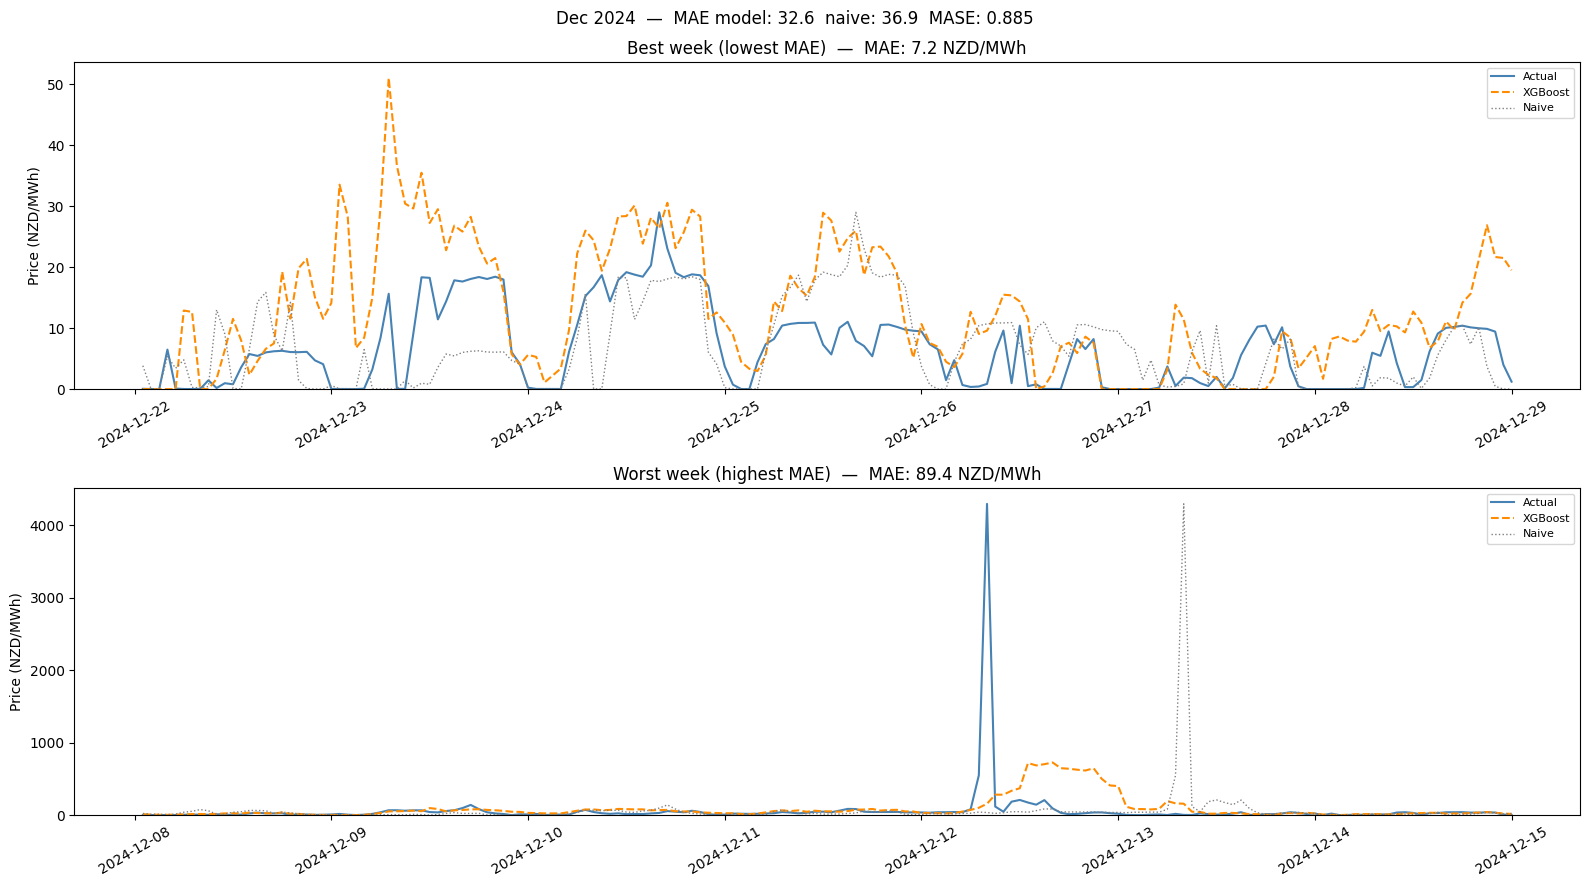

In [9]:
# ── Monthly Visualisation — Best & Worst Week per Fold ────────────────────────
#
# For each month, the 720 hours are split into ~4 weeks of 168h.
# The week with the lowest model MAE = Best week (model most confident)
# The week with the highest model MAE = Worst week (model struggling)
#
# Each figure: 2 subplots — actual vs XGBoost vs Naive

def find_best_worst_weeks(y_actual, y_model, timestamps, week_size=168):
    """Return (best_slice, worst_slice) as (start, end) index tuples."""
    n_weeks = len(y_actual) // week_size
    week_maes = []
    for w in range(n_weeks):
        s, e = w * week_size, (w + 1) * week_size
        mae  = mean_absolute_error(y_actual[s:e], y_model[s:e])
        week_maes.append((mae, s, e))
    best  = min(week_maes, key=lambda x: x[0])
    worst = max(week_maes, key=lambda x: x[0])
    return best, worst


for r in fold_results:
    best, worst = find_best_worst_weeks(r["y_actual"], r["y_model"], r["timestamps"])

    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(f"{r['month']}  —  MAE model: {r['mae_model']:.1f}  "
                 f"naive: {r['mae_naive']:.1f}  MASE: {r['mase']:.3f}",
                 fontsize=12)

    for ax, (mae, s, e), label in zip(
        axes,
        [best, worst],
        ["Best week (lowest MAE)", "Worst week (highest MAE)"]
    ):
        ts  = r["timestamps"][s:e]
        act = r["y_actual"][s:e]
        mod = r["y_model"][s:e]
        nav = r["y_naive"][s:e]

        ax.plot(ts, act, label="Actual",  color="steelblue",  linewidth=1.5)
        ax.plot(ts, mod, label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
        ax.plot(ts, nav, label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
        ax.set_title(f"{label}  —  MAE: {mae:.1f} NZD/MWh")
        ax.set_ylabel("Price (NZD/MWh)")
        ax.legend(fontsize=8, loc="upper right")
        ax.tick_params(axis="x", labelrotation=30)
        ax.set_ylim(bottom=0)   # enforce ≥ 0 on y-axis

    plt.tight_layout()
    plt.show()

In [10]:
# ── Final Model — trained on 80% for feature importance & seasonal plots ──────

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

xgb_model = XGBRegressor(**MODEL_PARAMS)
xgb_model.fit(X_train, y_train)

y_pred = np.clip(xgb_model.predict(X_test), 0, None)

mae_f  = mean_absolute_error(y_test, y_pred)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred))
r2_f   = r2_score(y_test, y_pred)

print("Final model — 80% train / 20% test")
print(f"  Train: {df['datetime_utc12'].iloc[0].date()} → {df['datetime_utc12'].iloc[split_index-1].date()}")
print(f"  Test : {df['datetime_utc12'].iloc[split_index].date()} → {df['datetime_utc12'].iloc[-1].date()}")
print(f"  MAE  : {mae_f:.4f}")
print(f"  RMSE : {rmse_f:.4f}")
print(f"  R²   : {r2_f:.4f}")

Final model — 80% train / 20% test
  Train: 2020-01-01 → 2023-12-31
  Test : 2023-12-31 → 2024-12-31
  MAE  : 55.5142
  RMSE : 126.5030
  R²   : 0.5493


                       feature  importance
el_price_dol_MWh_RDF2201_lag24        0.17
              rolling_mean_24h        0.13
el_price_dol_MWh_KIK2201_lag24        0.13
el_price_dol_MWh_WKM2201_lag24        0.05
el_price_dol_MWh_ISL2201_lag24        0.03
                target_lag_24h        0.02
    SI_TKA__active_storage_mm³        0.02
            rolling_mean_8760h        0.02
          SI_TKA__lake_level_m        0.02
el_price_dol_MWh_SFD2201_lag24        0.01
               tauranga_temp_c        0.01
                          hour        0.01
                     month_sin        0.01
          demand_GWh_UNI_lag24        0.01
          demand_GWh_USI_lag24        0.01
                  Diesel_lag24        0.01
             wellington_temp_c        0.01
el_price_dol_MWh_HAY2201_lag24        0.01
          demand_GWh_LSI_lag24        0.01
               target_lag_168h        0.01


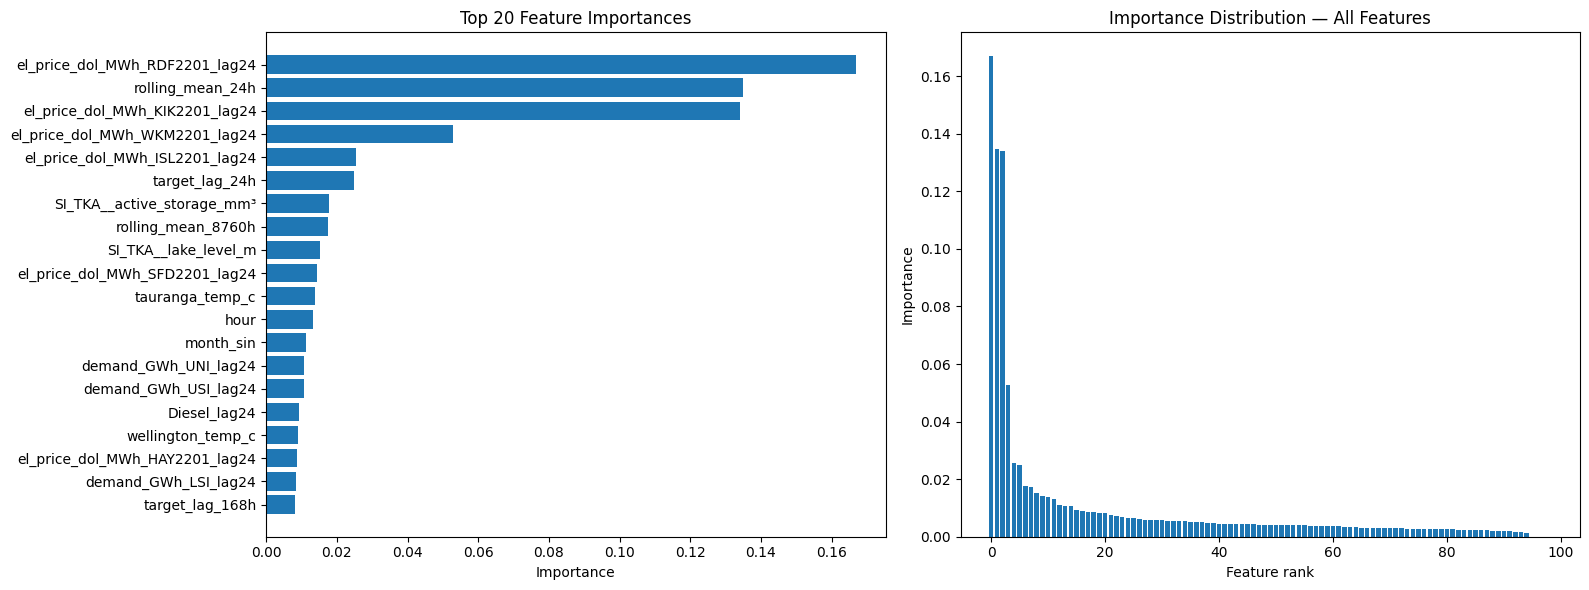

In [11]:
# ── Feature Importance ────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1])
axes[0].set_title("Top 20 Feature Importances")
axes[0].set_xlabel("Importance")

axes[1].bar(range(len(importance_df)), importance_df["importance"].values)
axes[1].set_title("Importance Distribution — All Features")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.show()

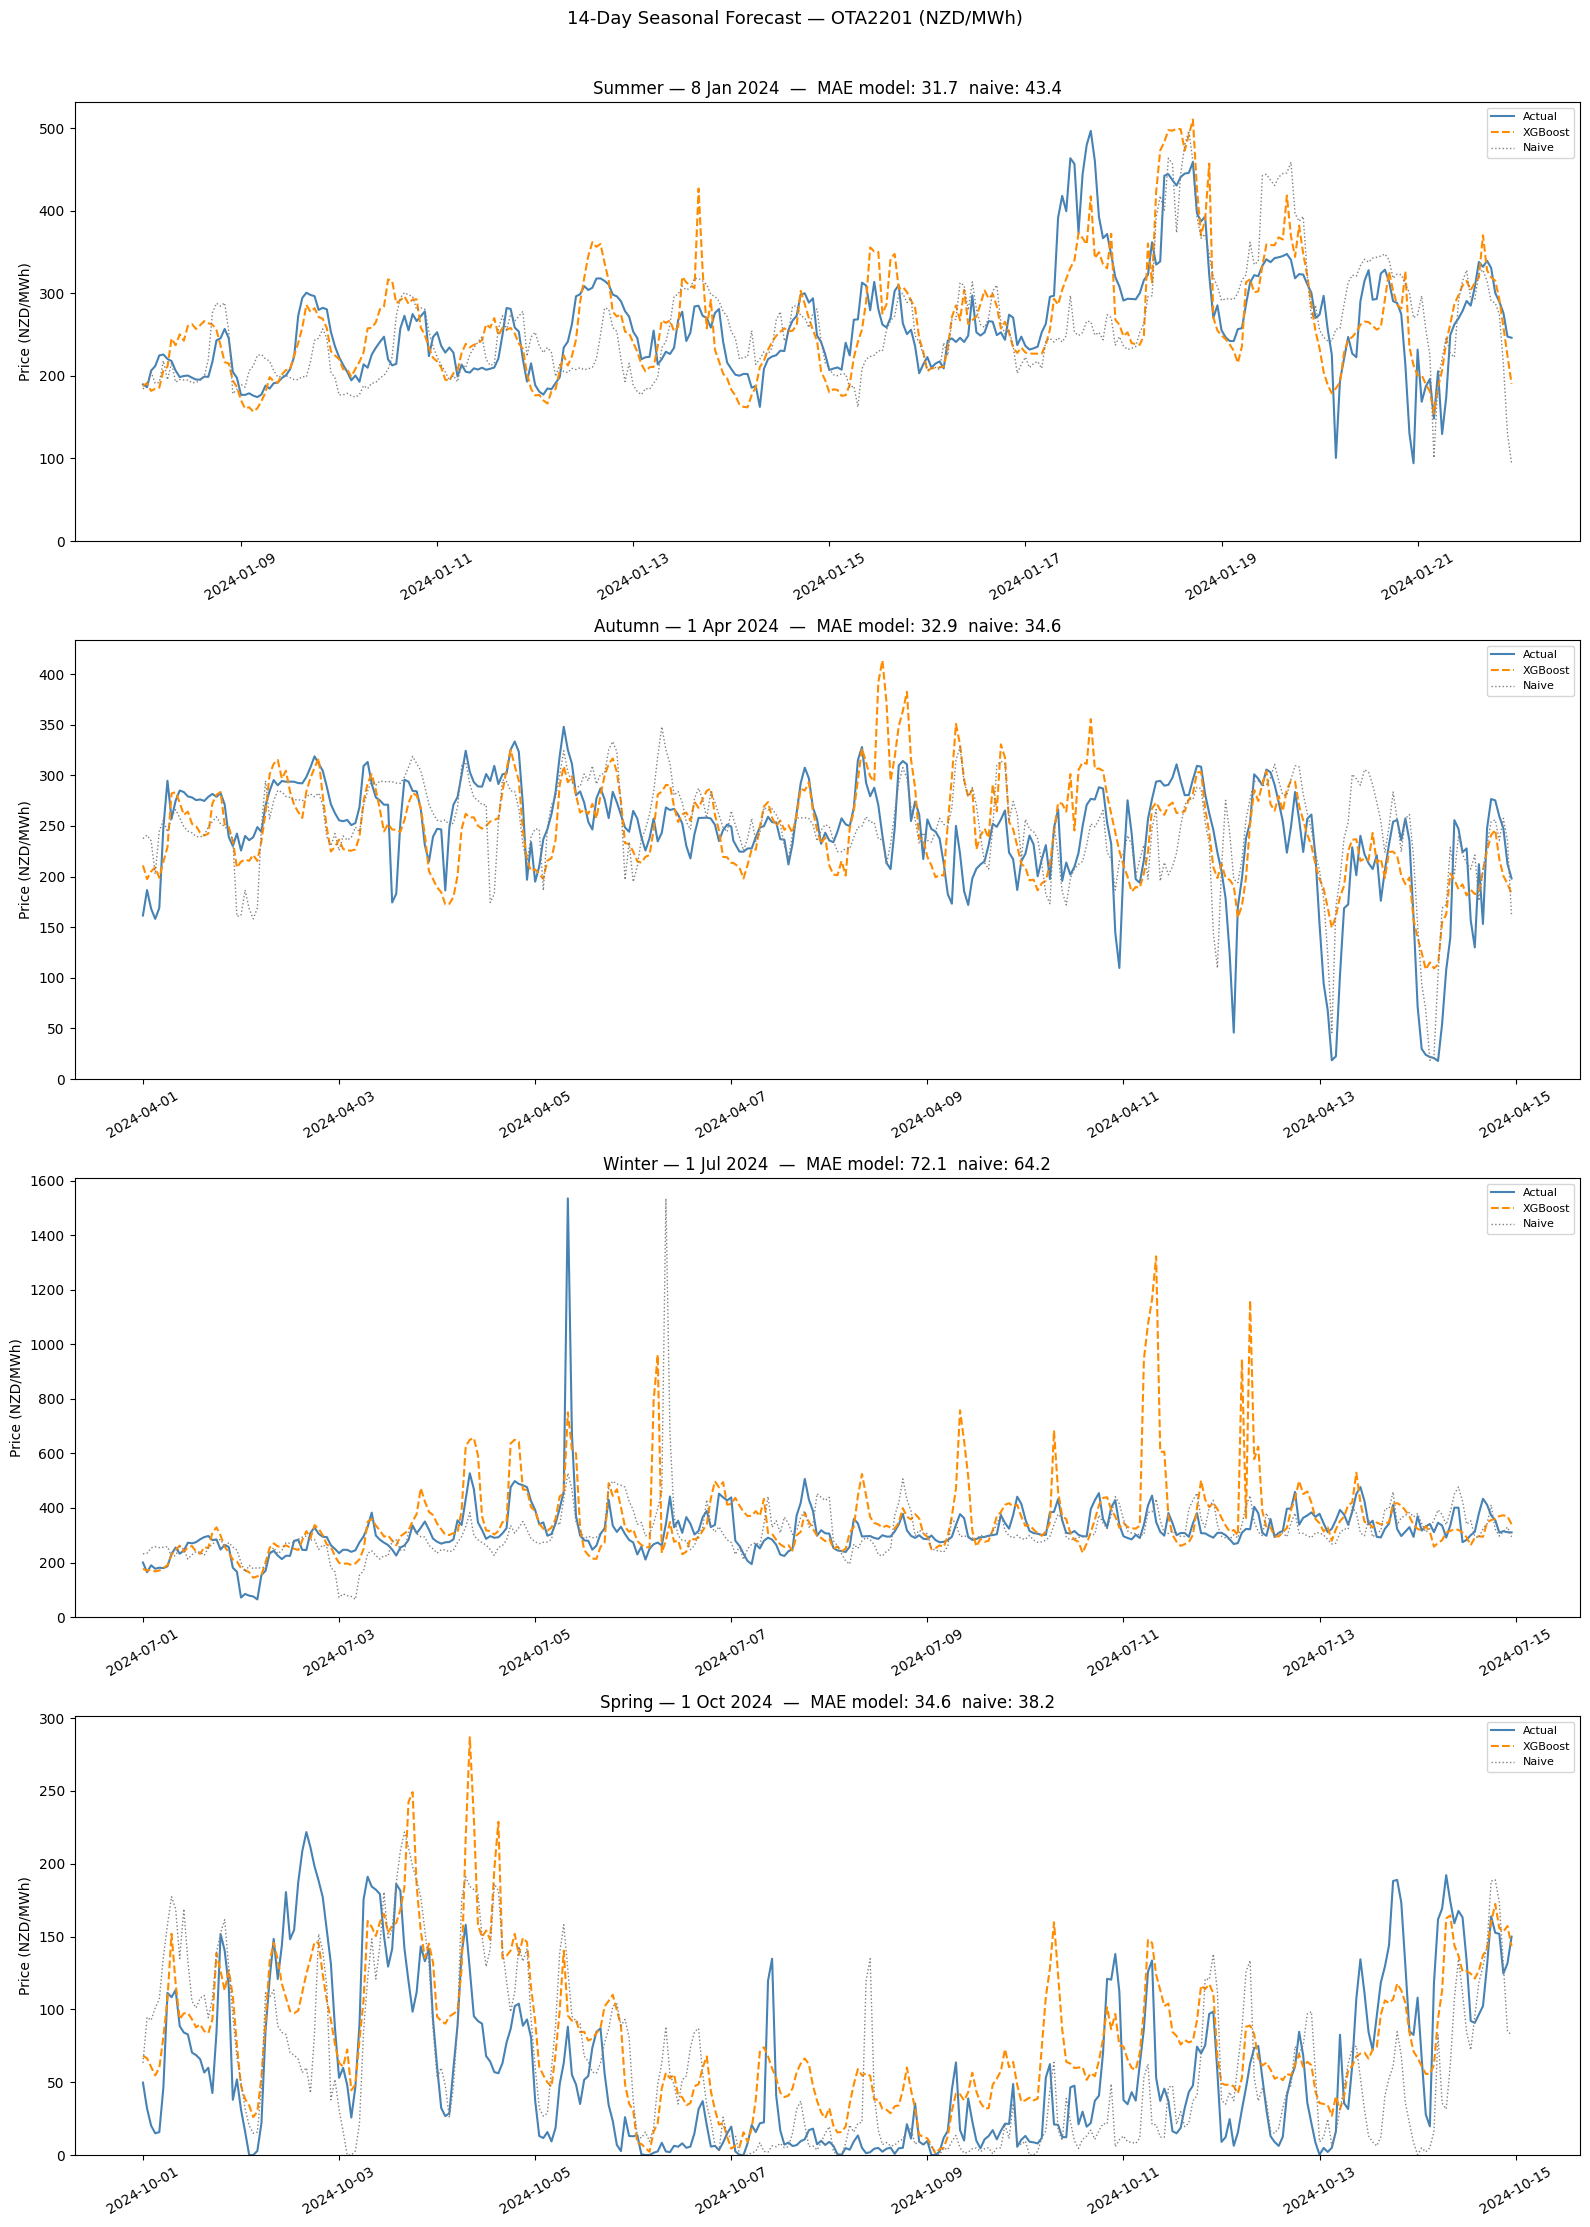

In [12]:
# ── Seasonal 14-Day Forecasts ─────────────────────────────────────────────────

def rolling_forecast(model, start_date, n_days=14):
    start_ts = pd.Timestamp(start_date)
    mask = (
        (df["datetime_utc12"] >= start_ts) &
        (df["datetime_utc12"] <  start_ts + pd.Timedelta(hours=n_days * 24))
    )
    d = df[mask].reset_index(drop=True)
    if len(d) < n_days * 24:
        raise ValueError(f"Not enough data from {start_date}")
    preds = np.clip(model.predict(d[feature_cols].values), 0, None)
    return preds, d[target_col].values, d["datetime_utc12"].values


seasons = {
    "Summer — 8 Jan 2024":  "2024-01-08",
    "Autumn — 1 Apr 2024":  "2024-04-01",
    "Winter — 1 Jul 2024":  "2024-07-01",
    "Spring — 1 Oct 2024":  "2024-10-01",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("14-Day Seasonal Forecast — OTA2201 (NZD/MWh)", fontsize=13, y=1.01)

for ax, (label, start) in zip(axes, seasons.items()):
    preds, actuals, ts = rolling_forecast(xgb_model, start)
    naive = df.set_index("datetime_utc12").loc[ts, "target_lag_24h"].values
    mae_m = mean_absolute_error(actuals, preds)
    mae_n = mean_absolute_error(actuals, naive)

    ax.plot(ts, actuals, label="Actual",  color="steelblue",  linewidth=1.5)
    ax.plot(ts, preds,   label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
    ax.plot(ts, naive,   label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
    ax.set_title(f"{label}  —  MAE model: {mae_m:.1f}  naive: {mae_n:.1f}")
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()